# Batch-wise causarray Analysis — Replogle-E-K562

This tutorial demonstrates the **batch fitting workflow** of `causarray` on a
subset of the Replogle et al. 2022 genome-wide CRISPRi screen in K562 cells
([Replogle et al. 2022, Cell](https://doi.org/10.1016/j.cell.2022.05.013)).

**Dataset (tutorial subset)**
- Full dataset: 309 915 cells × 8 563 genes, 2 021 perturbations
- Tutorial subset: top-200 most-abundant perturbations + 2 000 ctrl cells
  → **79 865 cells**, created by `prep_tutorial_data.py`

**Why batch fitting?**  
Running `fit_gcate` on 79 865 cells with 200 perturbations simultaneously
would require fitting a GLM with 201 treatment columns, which is both
numerically difficult and memory-intensive. `gcate_lfc_batch` avoids this
by pairing each batch of 15 perturbations with a fixed pool of control cells,
bounding peak memory to one batch at a time regardless of total pert count.

**Pipeline overview**
```
replogle_subset.h5ad
      |
      v  prep_causarray_data
   Y, A, X                  (count matrix, treatment indicators, covariates)
      |
      v  gcate_lfc_batch
   df_res                   (tau, std, stat, pvalue, padj per gene x pert)
      |
      v  visualization
   volcano, discovery bar chart
```


In [1]:
import sys
sys.path.insert(0, '../../..')

import time
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import scanpy as sc

from causarray import prep_causarray_data, gcate_lfc_batch
from causarray.gcate import plot_r

import causarray
print('causarray version:', causarray.__version__)


causarray version: 0.0.7


## 1. Load data

The subset was prepared by `prep_tutorial_data.py`. It contains the 200
perturbations with the most cells plus a random sample of 2 000 ctrl
(`non-targeting`) cells.


In [2]:
adata = sc.read_h5ad('replogle_subset.h5ad')
print(adata)

CTRL_LABEL = adata.uns['ctrl_label']   # 'non-targeting'
PERT_COL   = adata.uns['pert_col']     # 'gene'

vc = adata.obs[PERT_COL].value_counts()
print(f'\nCtrl cells  : {vc[CTRL_LABEL]}')
print(f'Pert cells  : {vc.drop(CTRL_LABEL).sum():,}  across {len(vc) - 1} perturbations')
print(f'Cells/pert  : median {vc.drop(CTRL_LABEL).median():.0f}, '
      f'range {vc.drop(CTRL_LABEL).min()}-{vc.drop(CTRL_LABEL).max()}')


AnnData object with n_obs × n_vars = 79865 × 8563
    obs: 'batch', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'guide_id', 'percent_mito', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'disease', 'cancer', 'cell_line', 'sex', 'age', 'perturbation', 'organism', 'perturbation_type', 'tissue_type', 'ncounts', 'ngenes', 'nperts', 'percent_ribo'
    var: 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'ensembl_id', 'ncounts', 'ncells'
    uns: 'ctrl_label', 'pert_col'

Ctrl cells  : 2000
Pert cells  : 77,865  across 200 perturbations
Cells/pert  : median 346, range 273-1996


## 2. Prepare causarray inputs


In [3]:
Y_raw = adata.X.toarray() if sp.issparse(adata.X) else np.array(adata.X)
Y = pd.DataFrame(Y_raw, columns=adata.var_names.tolist())
del Y_raw

A = (pd.get_dummies(adata.obs[PERT_COL].astype(str), drop_first=False)
       .drop(columns=[CTRL_LABEL]))

Y, A, X, X_A = prep_causarray_data(Y, A)

print(f'Y : {Y.shape}  (cells x genes)')
print(f'A : {A.shape}  (cells x perturbations)')
print(f'X : {X.shape}  X_A : {X_A.shape}')


Y : (79865, 8563)  (cells x genes)
A : (79865, 200)  (cells x perturbations)
X : (79865, 1)  X_A : (79865, 2)


## 3. Number of latent factors

We select `r` using the JIC criterion computed by `estimate_r`. The
pre-computed results are loaded from `replogle-r.csv` (generated by
`estimate_r_replogle.py`; re-run that script to reproduce them).

> **Why estimate `r` on control cells?**  
> `estimate_r` fits GCATE internally, which is expensive at full dataset scale
> (79 865 cells). The latent factors capture **confounding variation** that is
> present in the baseline (control) transcriptome, so a ctrl-priority subsample
> is both much faster and statistically equivalent to using all cells.  
> `estimate_r_replogle.py` uses 2 000 ctrl + 20 × ≤200 pert cells for this reason.  
> You can replicate this with the `max_cells` argument:
> ```python
> df_r = estimate_r(Y, X, A, r_values, family='nb', max_cells=6000)
> ```
> `estimate_r` will automatically prioritise control cells when subsampling.


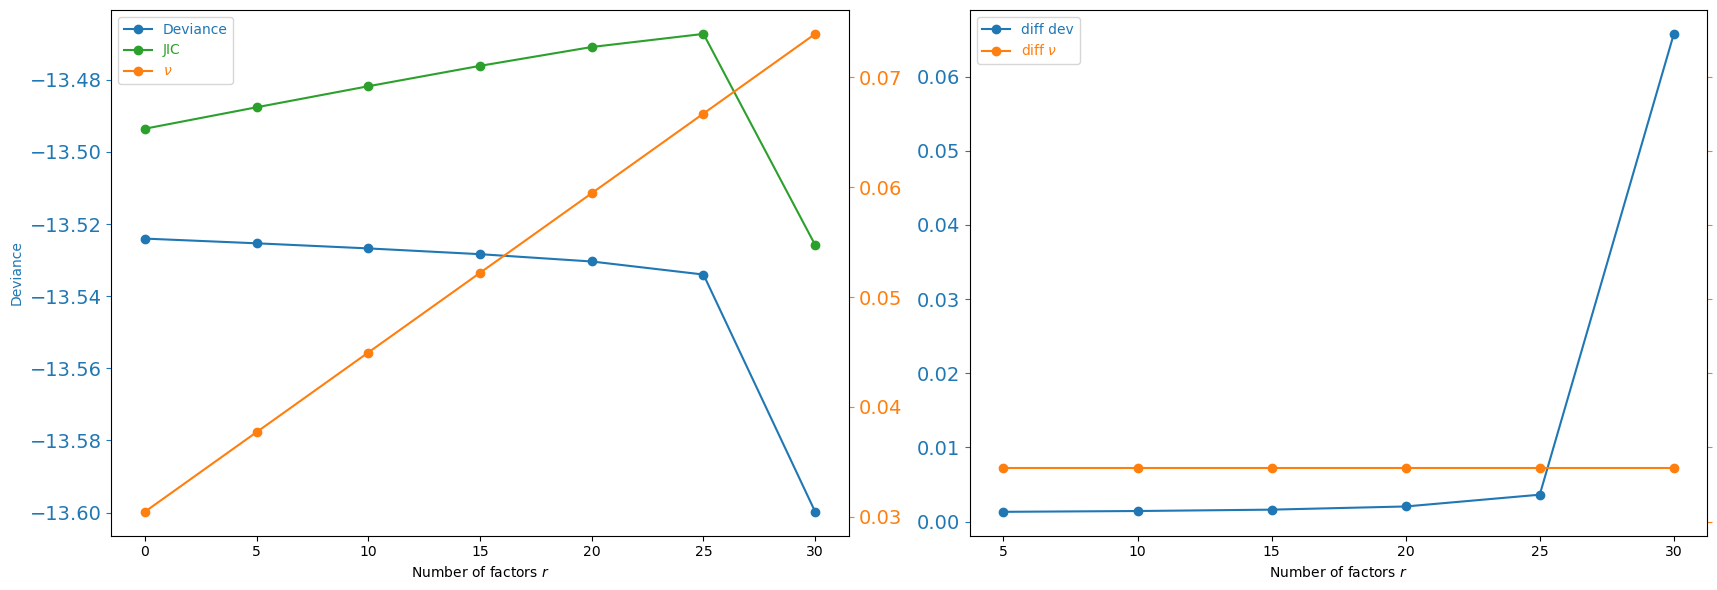


Selected r = 30  (min JIC)
 r   deviance       nu        JIC
 0 -13.524045 0.030448 -13.493596
 5 -13.525350 0.037698 -13.487652
10 -13.526765 0.044947 -13.481817
15 -13.528364 0.052197 -13.476167
20 -13.530392 0.059447 -13.470945
25 -13.534008 0.066696 -13.467311
30 -13.599773 0.073946 -13.525827


In [4]:
df_r = pd.read_csv('replogle-r.csv')
fig = plot_r(df_r)
plt.tight_layout()
plt.show()

best_r = int(df_r.loc[df_r['JIC'].idxmin(), 'r'])
print(f'\nSelected r = {best_r}  (min JIC)')
print(df_r.to_string(index=False))


## 4. Batch fitting with `gcate_lfc_batch`

Key parameters:

| Parameter | Value | Effect |
|-----------|-------|--------|
| `batch_size` | 15 | ~15 perts processed per GCATE call |
| `max_cells` | 2000 | <= 2000 pert cells per batch (ctrl added on top) |
| `n_ctrl` | 2000 | Fixed ctrl subsample shared across all batches |
| `usevar` | `'unequal'` | Welch treatment/control variance for inference |
| `cache_path` | `'replogle_results.h5'` | Resume from disk if interrupted |

With 200 perturbations and `batch_size=15`, `gcate_lfc_batch` internally
computes `n_batches = ceil(200 / 15) = 14` and then calls
`numpy.array_split` to distribute the remainder evenly, giving
**4 batches of 15 and 10 batches of 14** — no tiny tail batch.
Each batch has at most 2000 ctrl + 2000 pert cells = 4000 cells.


In [5]:
R = best_r

t0 = time.perf_counter()
df_res = gcate_lfc_batch(
    Y, X, A, R,
    W_A=X_A,
    batch_size=15,
    max_cells=2000,
    n_ctrl=2000,
    family='nb',
    lfc_kwargs=dict(usevar='unequal'),
    cache_path='replogle_results.h5',
    random_state=0,
    verbose=True,
    gcate_kwargs=dict(
        kwargs_es_1=dict(rel_tol=2e-4, max_iters=30),
        kwargs_es_2=dict(rel_tol=2e-4, max_iters=30),
    ),
)
t_total = time.perf_counter() - t0

print(f'\nTotal wall time: {t_total/60:.1f} min')
print(f'Result shape   : {df_res.shape}')
df_res.head()


[gcate_lfc_batch] Resuming: 14 batches already cached in 'replogle_results.h5'
'Pre-estimating dispersion on ctrl cell subsample...'


GCATE batches:   0%|          | 0/14 [00:00<?, ?batch/s]

GCATE batches: 100%|██████████| 14/14 [00:00<00:00, 83766.41batch/s]


Total wall time: 0.1 min
Result shape   : (1712600, 14)


,gene_names,tau,std,stat,rej,pvalue,padj,pvalue_emp_null_adj,padj_emp_null_adj,mean_control,mean_treated,estimable,trt,batch
0,LINC01409,0.000000,inf,NaN,0.0,NaN,NaN,NaN,NaN,0.072352,0.078497,True,AATF,0
1,LINC01128,-0.130575,2.677546,-0.048767,0.0,0.961208,0.972917,0.667758,0.999905,0.156995,0.137778,True,AATF,0
2,NOC2L,0.017141,0.247328,0.069305,0.0,0.944891,0.972917,0.826848,0.999905,0.824667,0.838924,True,AATF,0
3,KLHL17,0.000000,inf,NaN,0.0,NaN,NaN,NaN,NaN,0.077686,0.084759,True,AATF,0
4,HES4,0.000000,inf,NaN,0.0,NaN,NaN,NaN,NaN,0.137674,0.134297,True,AATF,0


## 5. Results

### 5.1 Discovery summary


In [6]:
FDR = 0.05
sig = df_res[df_res['padj'] < FDR]

print(f'Significant (padj < {FDR}): {len(sig):,} gene x pert pairs')
print(f'  Perturbations with >= 1 hit: {sig["trt"].nunique()}')
print(f'  Unique genes affected      : {sig["gene_names"].nunique():,}')

disc_per_pert = sig.groupby('trt').size().sort_values(ascending=False)
print(f'\nTop-10 perts by discovery count:')
print(disc_per_pert.head(10).to_string())


Significant (padj < 0.05): 20,450 gene x pert pairs
  Perturbations with >= 1 hit: 162
  Unique genes affected      : 3,831

Top-10 perts by discovery count:
trt
SUPT5H    1878
SUPT6H    1340
SFPQ       854
CSE1L      740
DDX47      561
HSPA9      547
PSMD6      509
NCBP2      496
TSR2       452
MED12      420


### 5.2 Volcano plot (all perturbations combined)


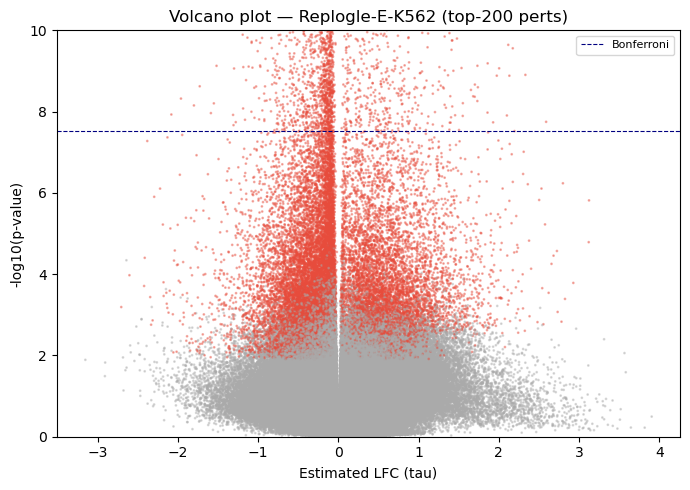

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))

colors = np.where(df_res['padj'] < FDR, '#e74c3c', '#aaaaaa')
ax.scatter(
    df_res['tau'], -np.log10(df_res['pvalue'].clip(1e-300)),
    c=colors, s=1, alpha=0.4, rasterized=True,
)
ax.axhline(-np.log10(0.05 / len(df_res)), color='navy', lw=0.8, ls='--',
           label='Bonferroni')
ax.set_ylim(0, 10)
ax.set_xlabel('Estimated LFC (tau)')
ax.set_ylabel('-log10(p-value)')
ax.set_title('Volcano plot — Replogle-E-K562 (top-200 perts)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### 5.3 Discovery count per perturbation

Each bar shows the number of significant genes (BH-adjusted p-value < 0.05) for one
perturbation. Wide variation in bar heights reflects genuine differences in perturbation
strength rather than technical artefacts, since causarray deconfounds shared latent
variation before testing.

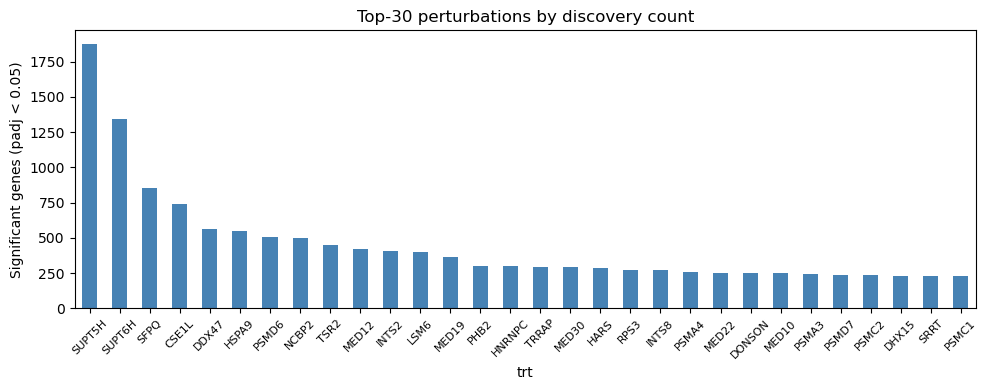

In [8]:
top_n = 30
top_disc = disc_per_pert.head(top_n)

fig, ax = plt.subplots(figsize=(10, 4))
top_disc.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_ylabel(f'Significant genes (padj < {FDR})')
ax.set_title(f'Top-{top_n} perturbations by discovery count')
ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout()
plt.show()


### 5.4 Comparison with a marginal Wilcoxon test

For context, we also compare each perturbation with the pooled non-targeting
control cells using a Wilcoxon rank-sum test on library-size-normalized,
log1p-transformed counts. Both methods are summarized at BH-adjusted
*p* < 0.05. Wilcoxon is a marginal comparison: unlike causarray, it does not
adjust for the observed covariates or estimated latent factors. Differences in
discovery counts can therefore reflect confounding, model assumptions, filtering,
or power and should not be interpreted as identifying false or true discoveries.


Backed X is stored as CSR but is being streamed by column (axis=1) slices, which is O(total_nnz) per chunk and can be ~100x slower. Consider running cx.data.convert_to_csc(path) once to store the matrix on its fast axis.


causarray: 20,450 significant pairs
Wilcoxon : 393,099 significant pairs
Median discoveries per perturbation: causarray=24, Wilcoxon=1979


,causarray,Wilcoxon
Perturbation,,
SUPT5H,1878,6709
SUPT6H,1340,6384
MED12,420,5842
MED30,292,5333
INTS2,406,5307
...,...,...
USP7,0,1
ANAPC15,0,0
CACNB3,0,0


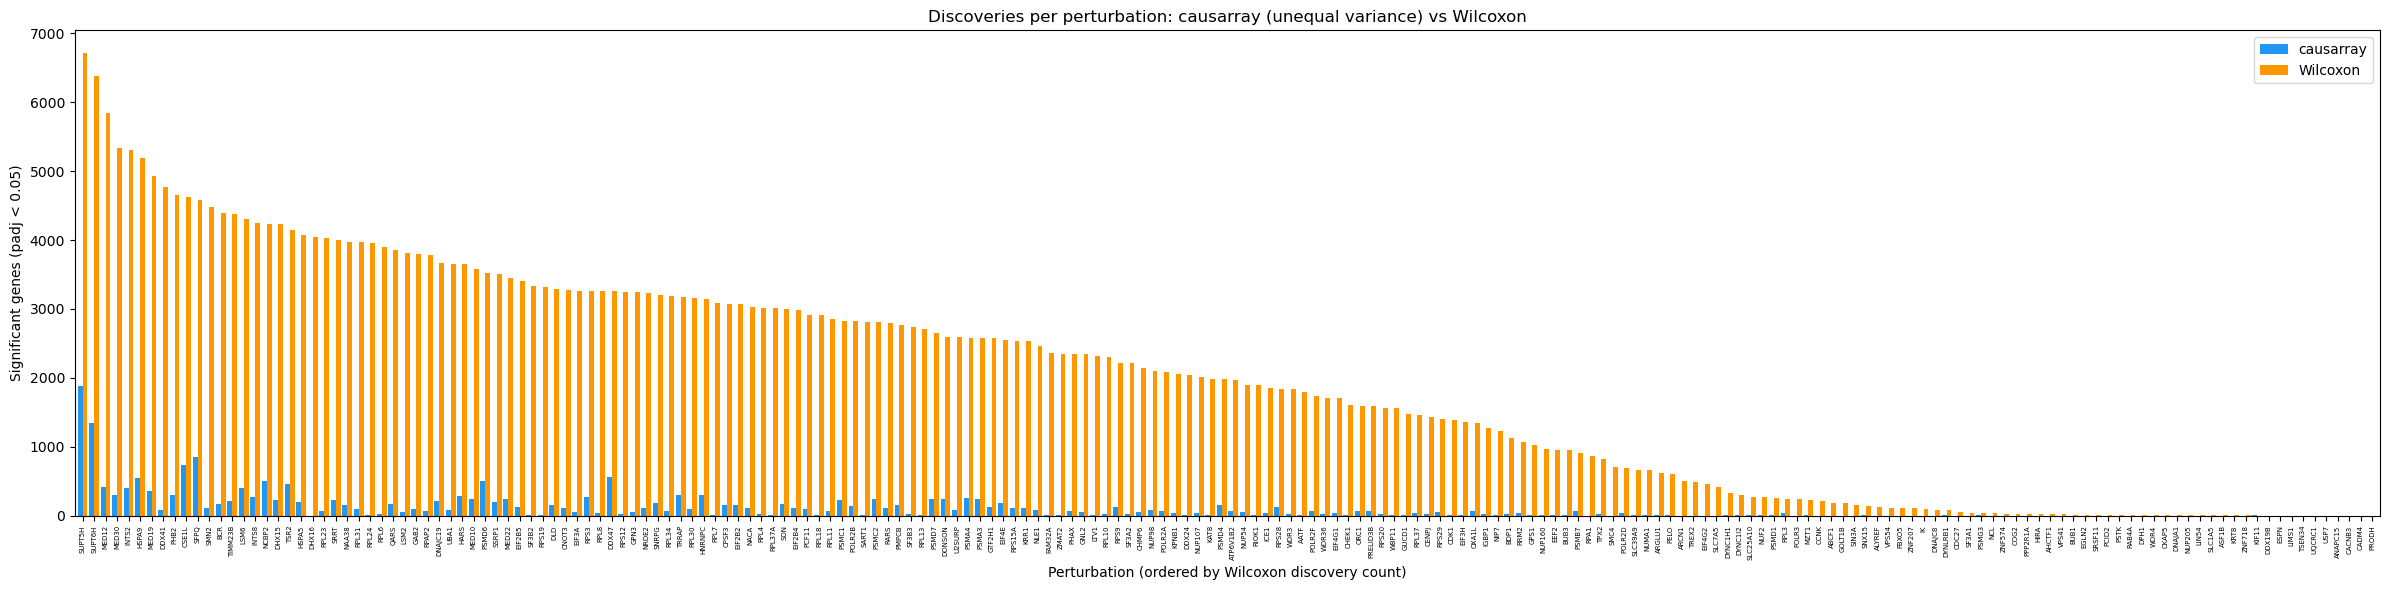

In [9]:
import os
import crispyx

# Wilcoxon is applied to normalized, log-transformed counts, following the
# same convention as the Adamson tutorial.
norm_path = 'replogle_subset_norm.h5ad'
if not os.path.exists(norm_path):
    crispyx.normalize_total_log1p(
        'replogle_subset.h5ad', output_path=norm_path, verbose=False
    )
wc_result = crispyx.wilcoxon_test(
    norm_path,
    perturbation_column=PERT_COL,
    control_label=CTRL_LABEL,
    verbose=False,
)

wc_count_map = {
    str(pert): int((np.asarray(wc_result[pert].pvalue_adj) < FDR).sum())
    for pert in wc_result.groups
}
all_perts = pd.Index(A.columns.astype(str), name='Perturbation')
comparison_counts = pd.DataFrame(index=all_perts)
comparison_counts['causarray'] = (
    disc_per_pert.rename(index=str).reindex(all_perts, fill_value=0).astype(int)
)
comparison_counts['Wilcoxon'] = (
    pd.Series(wc_count_map).reindex(all_perts, fill_value=0).astype(int)
)
comparison_counts = comparison_counts.sort_values(
    ['Wilcoxon', 'causarray'], ascending=False
)

print(f'causarray: {comparison_counts["causarray"].sum():,} significant pairs')
print(f'Wilcoxon : {comparison_counts["Wilcoxon"].sum():,} significant pairs')
print('Median discoveries per perturbation: ' +
      f'causarray={comparison_counts["causarray"].median():.0f}, ' +
      f'Wilcoxon={comparison_counts["Wilcoxon"].median():.0f}')
display(comparison_counts)

ax = comparison_counts.plot.bar(
    figsize=(24, 6), width=0.85,
    color={'causarray': '#2196F3', 'Wilcoxon': '#FF9800'},
)
ax.set_ylabel(f'Significant genes (padj < {FDR})')
ax.set_xlabel('Perturbation (ordered by Wilcoxon discovery count)')
ax.set_title('Discoveries per perturbation: causarray (unequal variance) vs Wilcoxon')
ax.tick_params(axis='x', rotation=90, labelsize=5)
plt.tight_layout()
plt.show()


#### Biological interpretation of the difference

The contrast is large: across 8,563 genes, Wilcoxon reports 393,099 significant gene--perturbation pairs (median 1,979 per perturbation), whereas causarray reports 20,450 (median 24). For SUPT5H specifically, the counts are 6,709 (78.3% of genes) and 1,878 (21.9%), respectively.

SUPT5H should not be treated as a negative-control perturbation for which a broad response is impossible. It encodes SPT5, the large subunit of DSIF and a central regulator of RNA polymerase II pausing and productive elongation. Acute depletion experiments show that SPT5 also stabilizes promoter-proximal polymerase II ([Aoi et al., 2021](https://pmc.ncbi.nlm.nih.gov/articles/PMC8687145/)), while nascent-transcription measurements show distinct effects at promoter-proximal and gene-body pauses ([Fong et al., 2022](https://pmc.ncbi.nlm.nih.gov/articles/PMC9555879/)). A widespread response to SUPT5H knockdown is therefore biologically credible, but the response need not be uniform across genes.

Even so, the causarray result is more plausible as a *selective list of robust gene-level responses* in this analysis. The original genome-scale Perturb-seq study organizes responses into co-regulated expression programs and perturbation modules rather than an undifferentiated whole-transcriptome effect ([Replogle et al., 2022](https://pmc.ncbi.nlm.nih.gov/articles/PMC9380471/)). A marginal Wilcoxon test applied to many cells can assign very small p-values to weak shared shifts, including indirect, cell-state, and compositional changes after library-size normalization. causarray adjusts for the measured covariates and estimated latent factors and uses the unequal-variance analysis appropriate for these repeated single-cell measurements, so its smaller SUPT5H set is easier to interpret as the genes with the strongest adjusted evidence. This is a plausibility argument, not proof that the additional Wilcoxon discoveries are false: for a core transcription factor such as SPT5, absolute-RNA or spike-in measurements would be needed to distinguish a global change in transcription from relative changes induced by normalization.